# Partial Derivatives

**This notebook is self-contained; it recaps surfaces and slicing before differentiating.**

On a curve, "the slope" is one number. On a **surface** it is not, standing on a hillside, the slope
depends entirely on which way you face. So the question has to be made precise: *slope in which
direction?*

The **partial derivative** answers the simplest version: the slope along one of the axes. And it turns
out to require no new machinery at all. Fix the other variable, and you are back to an ordinary
one-variable derivative.

## Learning objectives

- Compute a **partial derivative** by treating the other variable as a constant.
- Read $\partial f/\partial x$ and $\partial f/\partial y$ as slopes along the two axis directions.
- Recognize that each partial is itself a function of both variables.

## Background

For $f(x, y)$, the **partial derivative with respect to $x$** is written

$$\frac{\partial f}{\partial x} = \lim_{h\to 0}\frac{f(x + h,\, y) - f(x,\, y)}{h}$$

Compare it to the ordinary difference quotient from §3.3 and note that only $x$ changes, $y$ is held
fixed. That is the entire idea. The curly $\partial$ (said "partial") signals that other variables are
being held constant.

**In practice you never do the limit.** To differentiate with respect to $x$, treat $y$ as if it were
a number and apply the ordinary rules from §3.3. For $f(x,y) = x^2 + y^2$:

$$\frac{\partial f}{\partial x} = 2x \quad (\text{the } y^2 \text{ is a constant, so it dies}), \qquad
\frac{\partial f}{\partial y} = 2y$$

Each partial is itself a function of both variables, so it too can be plotted as a surface.

## This notebook covers

1. The definition: an ordinary derivative along one axis.
2. Computing both partials of a bowl.
3. Plotting the partials as surfaces.
4. The slope of a slice, drawn.
5. A less symmetric example.

**Prerequisites:** `U3-6_Multivariable-1_Surface3D`, `U3-3_Derivatives-2_Rules`

**Dataset:** none, functions are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from mpl_toolkits.mplot3d import Axes3D     # noqa: F401  (registers the 3d projection)

## 1. Fix one variable, differentiate the other

Work with the bowl $f(x, y) = x^2 + y^2$.

To get $\partial f/\partial x$, pretend $y$ is a fixed number. Then $y^2$ is a constant, its derivative
is zero, and the whole thing reduces to differentiating $x^2$:

$$\frac{\partial f}{\partial x} = 2x + 0 = 2x$$

By the mirror argument, $\partial f/\partial y = 2y$. Below, both are checked against the definition
numerically, using the same forward difference quotient as §3.3, but stepping only in one variable.

In [2]:
def f(x, y):
    return x**2 + y**2

def dfdx(x, y):
    return 2*x            # y treated as a constant

def dfdy(x, y):
    return 2*y            # x treated as a constant

# check against the definition: step in ONE variable only
h = 1e-6
x0, y0 = 1.5, -2.0

num_dx = (f(x0 + h, y0) - f(x0, y0)) / h      # only x moves
num_dy = (f(x0, y0 + h) - f(x0, y0)) / h      # only y moves

print(f"at the point (x, y) = ({x0}, {y0}):\n")
print(f"  df/dx :  rule {dfdx(x0, y0):9.5f}    definition {num_dx:9.5f}")
print(f"  df/dy :  rule {dfdy(x0, y0):9.5f}    definition {num_dy:9.5f}")

at the point (x, y) = (1.5, -2.0):

  df/dx :  rule   3.00000    definition   3.00000
  df/dy :  rule  -4.00000    definition  -4.00000


Rule and definition agree, as they must.

Notice something about this particular pair: $\partial f/\partial x$ does not involve $y$ at all, and $\partial f/\partial y$ does not involve $x$. That is a **special feature of this function**, not a general rule, section 4 shows the usual case, where each partial depends on both variables.


## 2. The partials as surfaces

Each partial derivative is a function of $x$ and $y$, so each has its own surface. Three panels: the
original function, then its two partials.

$\partial f/\partial x = 2x$ is a plane tilted along $x$ and flat along $y$, it says the slope in the
$x$ direction depends only on how far right you are. $\partial f/\partial y = 2y$ is the same plane
rotated a quarter turn.

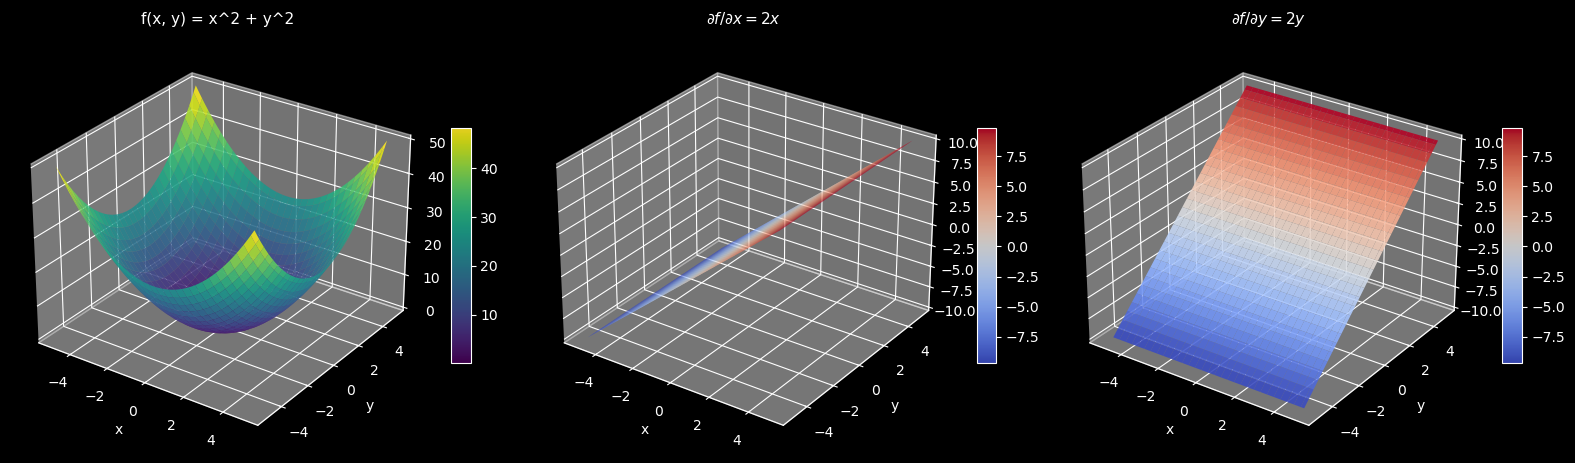

In [3]:
n = 60
xs = np.linspace(-5, 5, n)
ys = np.linspace(-5, 5, n)
X, Y = np.meshgrid(xs, ys)

Z = f(X, Y)
Zx = dfdx(X, Y)
Zy = dfdy(X, Y)

fig = plt.figure(figsize=(16, 5))
panels = [(Z, "f(x, y) = x^2 + y^2", "viridis"),
          (Zx, r"$\partial f / \partial x = 2x$", "coolwarm"),
          (Zy, r"$\partial f / \partial y = 2y$", "coolwarm")]
for k, (data, title, cmap) in enumerate(panels):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    surf = ax.plot_surface(X, Y, data, cmap=cmap, edgecolor="none", alpha=0.9)
    ax.view_init(elev=28, azim=-55)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("value")
    ax.set_title(title, pad=10, fontsize=11)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12)
plt.tight_layout()
plt.show()

## 3. A partial derivative is the slope of a slice

Here is the picture that makes the definition concrete. Fix $y = 2$ and walk along the $x$ direction:
the surface cuts down to the curve

$$f(x, 2) = x^2 + 4$$

an ordinary parabola. Its ordinary derivative is $2x$, which is exactly $\partial f/\partial x$.

**The partial derivative is nothing more than the slope of that sliced curve.** The left panel shows
the slice sitting on the surface; the right shows the same slice flattened out with its tangent line
at $x = 1.5$.

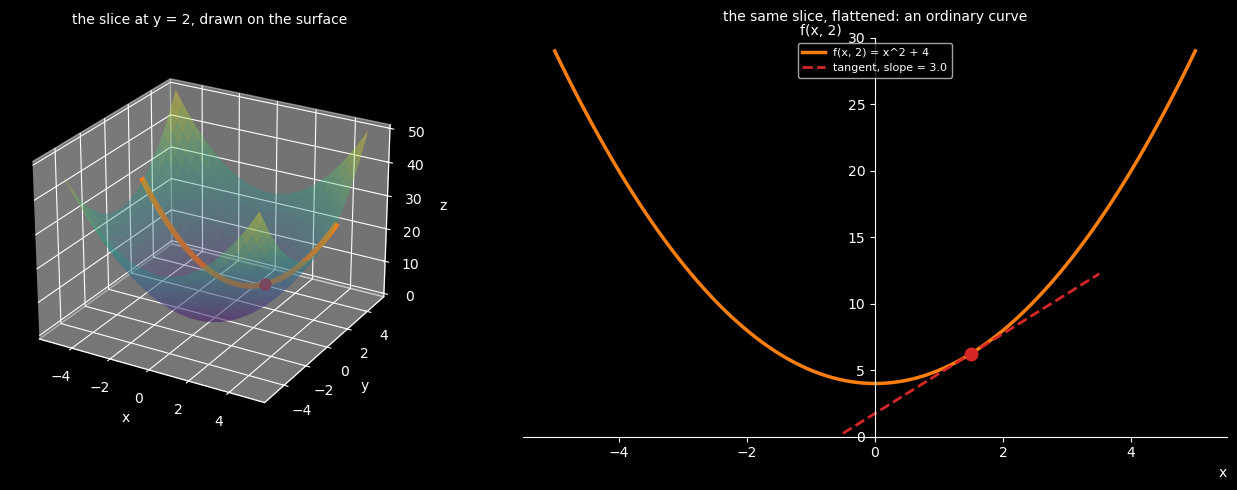

slope of the sliced curve at x = 1.5:   3.0000
partial derivative df/dx at (1.5, 2.0):  3.0000   -- the same number


In [4]:
y_fixed = 2.0
x_at = 1.5

fig = plt.figure(figsize=(14, 5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none", alpha=0.35)
line = np.linspace(-5, 5, 100)
ax.plot(line, np.full_like(line, y_fixed), f(line, y_fixed), color="tab:orange", lw=4)
ax.plot([x_at], [y_fixed], [f(x_at, y_fixed)], "o", color="tab:red", markersize=8)
ax.view_init(elev=25, azim=-60)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"the slice at y = {y_fixed:.0f}, drawn on the surface", pad=10, fontsize=10)

ax = fig.add_subplot(1, 2, 2)
ax.plot(line, f(line, y_fixed), color="tab:orange", lw=2.5, label=f"f(x, {y_fixed:.0f}) = x^2 + 4")
slope = dfdx(x_at, y_fixed)
seg = np.linspace(x_at - 2, x_at + 2, 10)
ax.plot(seg, f(x_at, y_fixed) + slope * (seg - x_at), "--", color="tab:red", lw=2,
        label=f"tangent, slope = {slope:.1f}")
ax.plot(x_at, f(x_at, y_fixed), "o", color="tab:red", markersize=9)
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("f(x, 2)", loc="top", rotation=0)
ax.set_ylim(0, 30)
ax.legend(loc="upper center", fontsize=8)
ax.set_title("the same slice, flattened: an ordinary curve", pad=12, fontsize=10)

plt.tight_layout()
plt.show()

print(f"slope of the sliced curve at x = {x_at}:   {slope:.4f}")
print(f"partial derivative df/dx at ({x_at}, {y_fixed}):  {dfdx(x_at, y_fixed):.4f}   -- the same number")

## 4. A less symmetric example

The bowl was tidy: each partial depended on only its own variable. That is unusual. Take

$$g(x, y) = x^2 y + 5y$$

Differentiating with respect to $x$, the $y$ is a constant multiplier that comes along for the ride,
and $5y$ is a constant that dies:

$$\frac{\partial g}{\partial x} = 2xy$$

Differentiating with respect to $y$, now $x^2$ is the constant multiplier:

$$\frac{\partial g}{\partial y} = x^2 + 5$$

Note that $\partial g/\partial x$ depends on **both** variables, the slope in the $x$ direction
changes as you move in $y$. That is the normal situation.

In [5]:
def g(x, y):
    return x**2 * y + 5*y

def dgdx(x, y):
    return 2*x*y

def dgdy(x, y):
    return x**2 + 5

h = 1e-6
for (px, py) in [(1.0, 1.0), (2.0, -1.0), (-1.5, 3.0)]:
    nx = (g(px + h, py) - g(px, py)) / h
    ny = (g(px, py + h) - g(px, py)) / h
    print(f"at ({px:5.1f}, {py:5.1f}):  dg/dx rule {dgdx(px, py):8.4f}  def {nx:8.4f}   |   "
          f"dg/dy rule {dgdy(px, py):8.4f}  def {ny:8.4f}")

at (  1.0,   1.0):  dg/dx rule   2.0000  def   2.0000   |   dg/dy rule   6.0000  def   6.0000
at (  2.0,  -1.0):  dg/dx rule  -4.0000  def  -4.0000   |   dg/dy rule   9.0000  def   9.0000
at ( -1.5,   3.0):  dg/dx rule  -9.0000  def  -9.0000   |   dg/dy rule   7.2500  def   7.2500


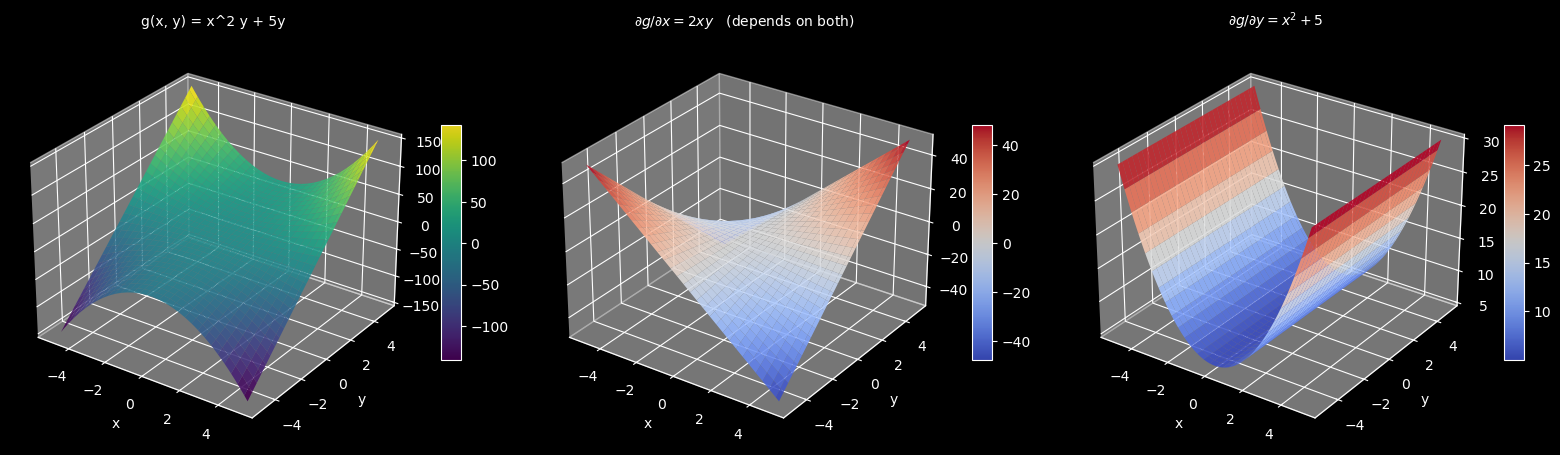

In [6]:
Zg  = g(X, Y)
Zgx = dgdx(X, Y)
Zgy = dgdy(X, Y)

fig = plt.figure(figsize=(16, 5))
panels = [(Zg, "g(x, y) = x^2 y + 5y", "viridis"),
          (Zgx, r"$\partial g / \partial x = 2xy$   (depends on both)", "coolwarm"),
          (Zgy, r"$\partial g / \partial y = x^2 + 5$", "coolwarm")]
for k, (data, title, cmap) in enumerate(panels):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    surf = ax.plot_surface(X, Y, data, cmap=cmap, edgecolor="none", alpha=0.9)
    ax.view_init(elev=28, azim=-55)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("value")
    ax.set_title(title, pad=10, fontsize=10)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=12)
plt.tight_layout()
plt.show()

## 5. Summary

- A **partial derivative** is an ordinary derivative taken along one axis, with the other variable
  **held constant**. The curly $\partial$ marks that.
- To compute it, treat the other variable as a number and use the §3.3 rules, no new technique.
- Geometrically it is the **slope of a slice** through the surface.
- Each partial is itself a function of both variables and generally depends on both.
- A surface has no single "slope": it has one per direction, and the partials are just the two along
  the axes.

Next: bundling the two partials into a single object that points **straight uphill**, the **gradient**
(`U3-6_Multivariable-3_GradientField`).